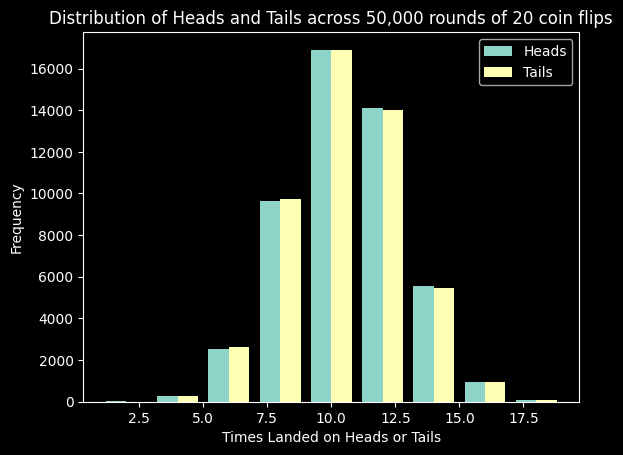

In [15]:
# Coin toss simultor with the results displayed
# in a a distribution histogram

import random
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# Define function for parallel processing of
# simulated coin flips for a distribution

def flip_rounds(flips):
        heads = 0
        tails = 0
        for _ in range(flips):
            coin_flip = random.randint(1, 2)
            if coin_flip == 1:
                heads += 1
            else:
                tails += 1
        return(heads, tails)

rounds = 50000
flips = 20

with ProcessPoolExecutor(max_workers=30) as executor:
    all_results = list(executor.map(flip_rounds, [flips]*rounds))

# Seperate Heads and Tails so we can display them in
# a histogram
heads_list = [result[0] for result in all_results]
tails_list = [result[1] for result in all_results]

plt.hist([heads_list, tails_list], bins=range(
    1, 21, 2), label=['Heads', 'Tails'])
plt.xlabel('Times Landed on Heads or Tails')
plt.ylabel('Frequency')
plt.title(
    f'Distribution of Heads and Tails across {rounds:,} rounds of {flips} coin flips')
plt.legend()
plt.show()


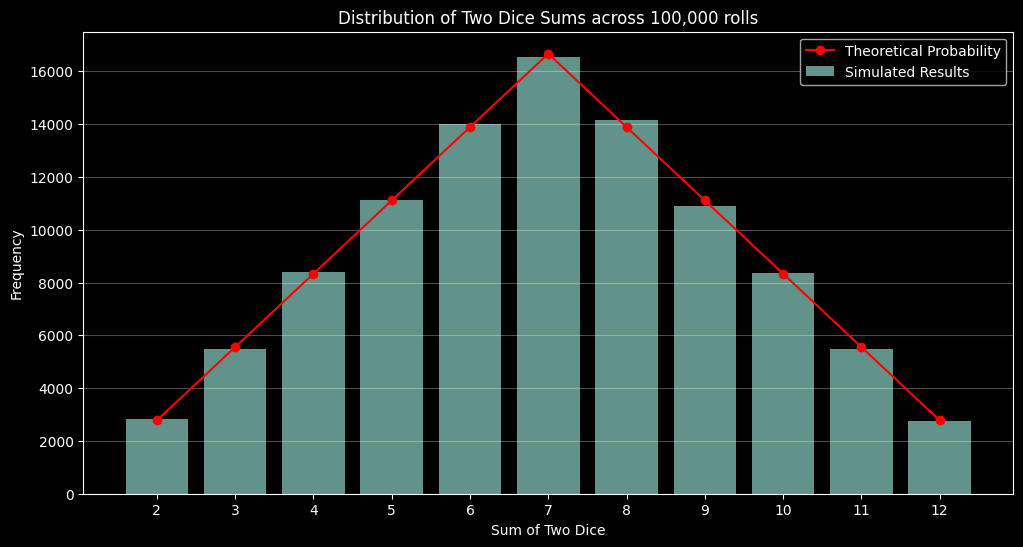

In [ ]:
import random
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# Define function for parallel processing of
# simulated dice rolls for a distribution
def roll_dice_pair(num_rolls):
    # Dictionary to count occurrences of each sum
    results = {2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0}

    for _ in range(num_rolls):
        die1 = random.randint(1, 6)
        die2 = random.randint(1, 6)
        dice_sum = die1 + die2
        results[dice_sum] += 1

    return results

# Number of simulation rounds and rolls per round
rounds = 10000
rolls_per_round = 10

# Run simulations in parallel
with ProcessPoolExecutor(max_workers=30) as executor:
    all_results = list(executor.map(roll_dice_pair, [rolls_per_round]*rounds))

# Combine results from all rounds
combined_results = {i: 0 for i in range(2, 13)}
for result in all_results:
    for dice_sum, count in result.items():
        combined_results[dice_sum] += count

# Extract data for plotting
sums = list(combined_results.keys())
frequencies = list(combined_results.values())

# Calculate total rolls and theoretical probability
total_rolls = sum(frequencies)
theoretical_probs = [0, 0, 1/36, 2/36, 3/36, 4/36, 5/36, 6/36, 5/36, 4/36, 3/36, 2/36, 1/36]
theoretical_counts = [p * total_rolls for p in theoretical_probs]

# Create the histogram
plt.figure(figsize=(12, 6))

# Plot the actual frequencies
plt.bar(sums, frequencies, alpha=0.7, label='Simulated Results')

# Plot the theoretical frequencies
plt.plot(sums, [theoretical_counts[i] for i in sums], 'ro-', label='Theoretical Probability')

plt.xlabel('Sum of Two Dice')
plt.ylabel('Frequency')
plt.title(f'Distribution of Two Dice Sums across {total_rolls:,} rolls')
plt.xticks(range(2, 13))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()